In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("outputs/cleaned_data.csv")

df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,weather_condition,holiday_promotion,competitor_pricing,seasonality,revenue
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,4254.50
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,9451.50
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,1819.35
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,1995.92
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,1030.96


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 73100
Columns: 16


In [4]:
df["revenue"] = df["units_sold"] * df["price"]

df[["units_sold","price","revenue"]].head()

,units_sold,price,revenue
0,127,33.50,4254.50
1,150,63.01,9451.50
2,65,27.99,1819.35
3,61,32.72,1995.92
4,14,73.64,1030.96


In [5]:
category_revenue = (
    df.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Furniture      1.115118e+08
Groceries      1.109845e+08
Clothing       1.096510e+08
Toys           1.096424e+08
Electronics    1.084391e+08
Name: revenue, dtype: float64

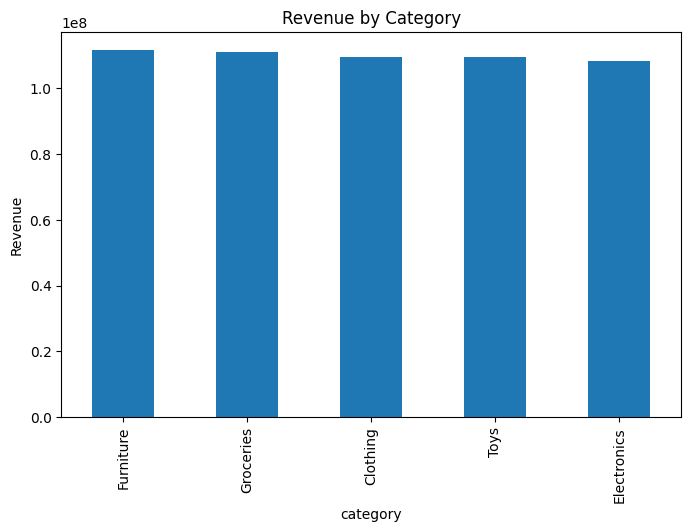

In [6]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

In [7]:
df.groupby("category")["units_sold"].sum().sort_values(ascending=False)

category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: units_sold, dtype: int64

In [8]:
region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

region
East     1.387121e+08
South    1.384836e+08
North    1.372553e+08
West     1.357780e+08
Name: revenue, dtype: float64

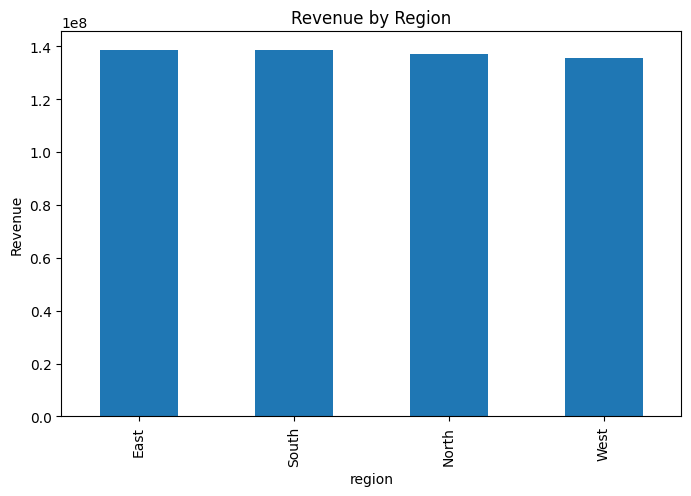

In [9]:
plt.figure(figsize=(8,5))

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.ylabel("Revenue")

plt.show()

In [10]:
df.groupby("region")["units_sold"].mean()

region
East     136.861137
North    136.326860
South    137.060666
West     135.605838
Name: units_sold, dtype: float64

In [11]:
season_sales = (
    df.groupby("seasonality")["units_sold"]
    .mean()
    .sort_values(ascending=False)
)

season_sales

seasonality
Autumn    137.782444
Winter    136.830790
Spring    135.826828
Summer    135.428298
Name: units_sold, dtype: float64

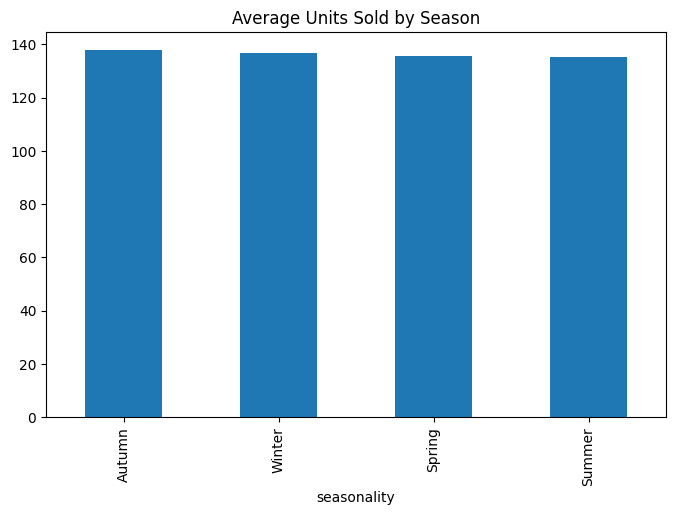

In [12]:
plt.figure(figsize=(8,5))

season_sales.plot(kind="bar")

plt.title("Average Units Sold by Season")

plt.show()

In [13]:
df.groupby("holiday_promotion")["units_sold"].mean()

holiday_promotion
0    136.505375
1    136.423926
Name: units_sold, dtype: float64

In [14]:
holiday_analysis = (
    df.groupby("holiday_promotion")["revenue"]
    .mean()
)

holiday_analysis

holiday_promotion
0    7523.668903
1    7530.509827
Name: revenue, dtype: float64

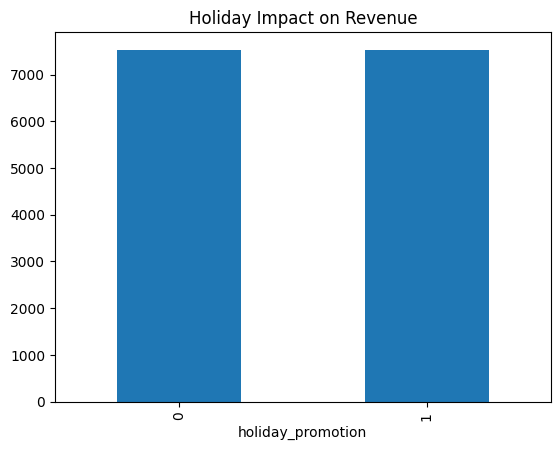

In [15]:
holiday_analysis.plot(kind="bar")

plt.title("Holiday Impact on Revenue")

plt.show()

In [16]:
weather_sales = (
    df.groupby("weather_condition")["units_sold"]
    .mean()
    .sort_values(ascending=False)
)

weather_sales

weather_condition
Sunny     138.028650
Cloudy    136.758324
Snowy     135.911559
Rainy     135.160028
Name: units_sold, dtype: float64

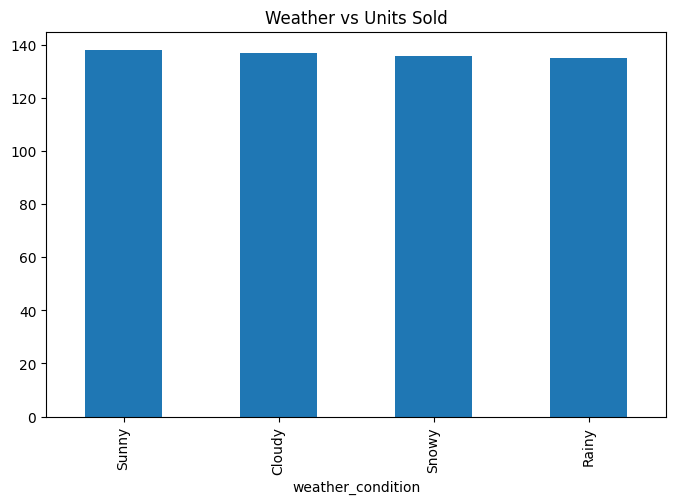

In [17]:
plt.figure(figsize=(8,5))

weather_sales.plot(kind="bar")

plt.title("Weather vs Units Sold")

plt.show()

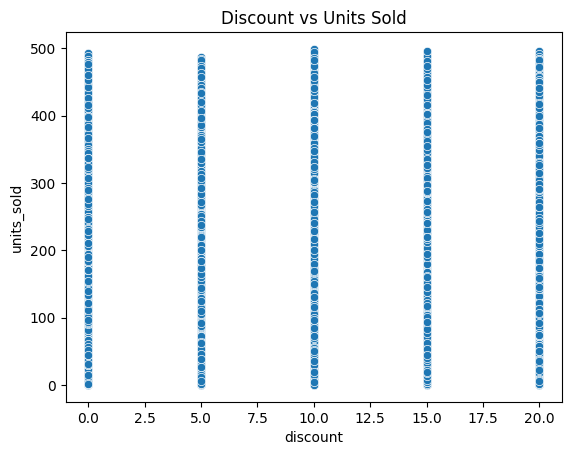

In [18]:
sns.scatterplot(
    data=df,
    x="discount",
    y="units_sold"
)

plt.title("Discount vs Units Sold")

plt.show()

In [19]:
df[["discount","units_sold"]].corr()

,discount,units_sold
discount,1.000000,0.002576
units_sold,0.002576,1.000000


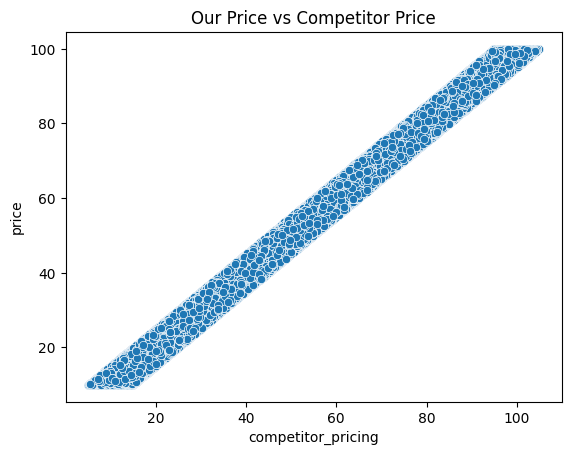

In [20]:
sns.scatterplot(
    data=df,
    x="competitor_pricing",
    y="price"
)

plt.title("Our Price vs Competitor Price")

plt.show()

In [21]:
df[["competitor_pricing","price"]].corr()

,competitor_pricing,price
competitor_pricing,1.0000,0.9939
price,0.9939,1.0000


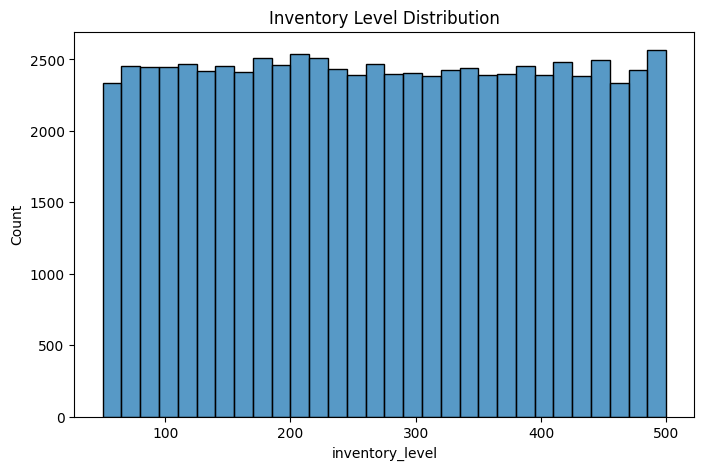

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["inventory_level"],
    bins=30
)

plt.title("Inventory Level Distribution")

plt.show()

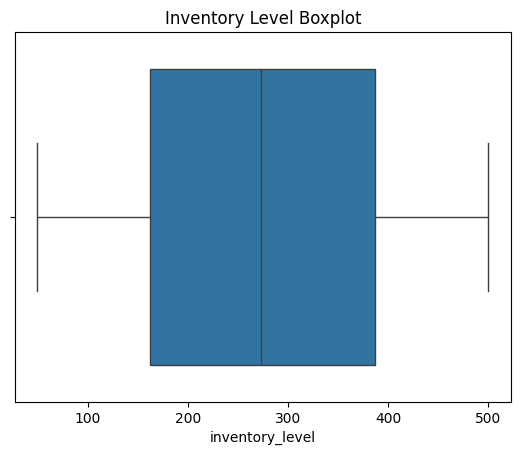

In [23]:
sns.boxplot(
    x=df["inventory_level"]
)

plt.title("Inventory Level Boxplot")

plt.show()

In [24]:
top_products = (
    df.groupby("product_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)

product_id
P0016    508472
P0020    507708
P0014    507622
P0015    507283
P0005    503648
P0009    502086
P0013    500619
P0017    500510
P0011    499362
P0007    499321
Name: units_sold, dtype: int64

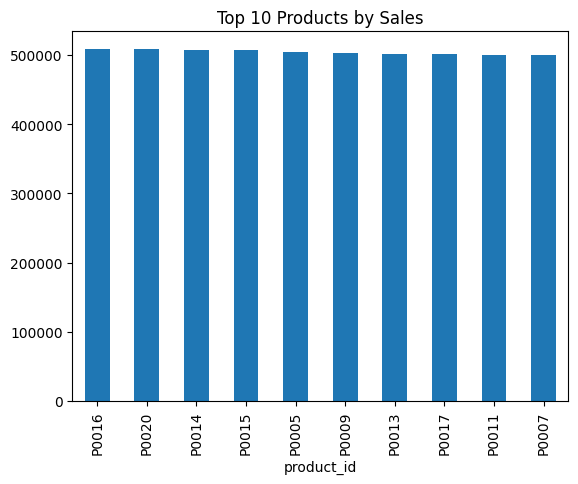

In [25]:
top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Sales")

plt.show()

In [26]:
numeric_cols = [
    "inventory_level",
    "units_sold",
    "units_ordered",
    "demand_forecast",
    "price",
    "discount",
    "competitor_pricing"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,competitor_pricing
inventory_level,1.000000,0.589995,0.001060,0.588561,0.009140,0.004889,0.009365
units_sold,0.589995,1.000000,-0.000930,0.996853,0.001082,0.002576,0.001259
units_ordered,0.001060,-0.000930,1.000000,-0.001102,0.004212,-0.000938,0.004596
demand_forecast,0.588561,0.996853,-0.001102,1.000000,0.000675,0.002338,0.000844
price,0.009140,0.001082,0.004212,0.000675,1.000000,0.001509,0.993900
discount,0.004889,0.002576,-0.000938,0.002338,0.001509,1.000000,0.001958
competitor_pricing,0.009365,0.001259,0.004596,0.000844,0.993900,0.001958,1.000000


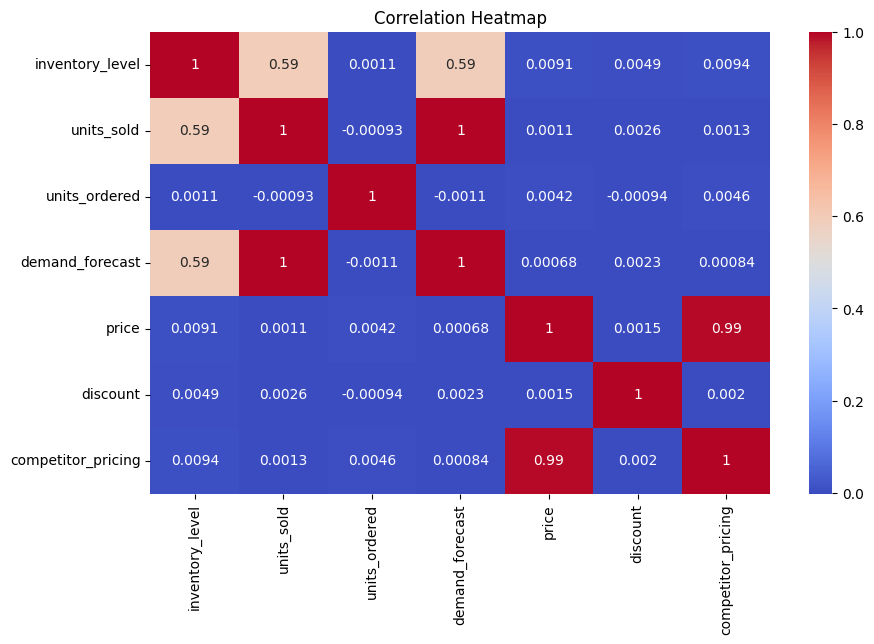

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
print("Top Revenue Category:")
print(category_revenue.idxmax())

print("\nBest Region:")
print(region_revenue.idxmax())

print("\nMost Sold Product:")
print(top_products.idxmax())

Top Revenue Category:
Furniture

Best Region:
East

Most Sold Product:
P0016
